## **STOCK PRICE PREDICTION**

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf

In [ ]:
# Download Tesla stock data from Yahoo Finance
stock_data = yf.download("TSLA", start="2016-01-01", end="2026-01-01")

# Show first 5 rows (Raw Data)
print("Raw Data from Yahoo Finance:")
print(stock_data.head())
stock_data.shape

/tmp/ipython-input-283/1800610284.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download("TSLA", start="2016-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed

Raw Data from Yahoo Finance:
Price           Close       High        Low       Open     Volume
Ticker           TSLA       TSLA       TSLA       TSLA       TSLA
Date                                                             
2016-01-04  14.894000  15.425333  14.600000  15.381333  102406500
2016-01-05  14.895333  15.126000  14.666667  15.090667   47802000
2016-01-06  14.602667  14.670000  14.398667  14.666667   56686500
2016-01-07  14.376667  14.562667  14.244667  14.279333   53314500
2016-01-08  14.066667  14.696000  14.051333  14.524000   54421500


(2514, 5)

In [ ]:
# Convert into DataFrame
df = pd.DataFrame(stock_data)

# Select required columns
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]

print("\nConverted DataFrame:")
print(df.head())


Converted DataFrame:
Price            Open       High        Low      Close     Volume
Ticker           TSLA       TSLA       TSLA       TSLA       TSLA
Date                                                             
2016-01-04  15.381333  15.425333  14.600000  14.894000  102406500
2016-01-05  15.090667  15.126000  14.666667  14.895333   47802000
2016-01-06  14.666667  14.670000  14.398667  14.602667   56686500
2016-01-07  14.279333  14.562667  14.244667  14.376667   53314500
2016-01-08  14.524000  14.696000  14.051333  14.066667   54421500


In [ ]:
print("\nShape of DataFrame:", df.shape)


Shape of DataFrame: (2514, 5)


In [ ]:
print("\nData Information:")
df.info()


Data Information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2514 entries, 2016-01-04 to 2025-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Open, TSLA)    2514 non-null   float64
 1   (High, TSLA)    2514 non-null   float64
 2   (Low, TSLA)     2514 non-null   float64
 3   (Close, TSLA)   2514 non-null   float64
 4   (Volume, TSLA)  2514 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 117.8 KB


In [ ]:
df.columns

MultiIndex([(  'Open', 'TSLA'),
            (  'High', 'TSLA'),
            (   'Low', 'TSLA'),
            ( 'Close', 'TSLA'),
            ('Volume', 'TSLA')],
           names=['Price', 'Ticker'])

**Create Target Variables**

In [ ]:
# 1 = BUY (Price increases tomorrow)
# 0 = SELL (Price decreases tomorrow)

df['Target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

In [ ]:
# Remove last row (NaN created by shift)
df.dropna(inplace=True)

In [ ]:
print(df.head())

Price            Open       High        Low      Close     Volume Target
Ticker           TSLA       TSLA       TSLA       TSLA       TSLA       
Date                                                                    
2016-01-04  15.381333  15.425333  14.600000  14.894000  102406500      1
2016-01-05  15.090667  15.126000  14.666667  14.895333   47802000      0
2016-01-06  14.666667  14.670000  14.398667  14.602667   56686500      0
2016-01-07  14.279333  14.562667  14.244667  14.376667   53314500      0
2016-01-08  14.524000  14.696000  14.051333  14.066667   54421500      0


**Create Features**

In [ ]:
df['MA10'] = df['Close'].rolling(10).mean()
df['MA50'] = df['Close'].rolling(50).mean()

In [ ]:
df['Open-Close'] = df['Open'] - df['Close']

In [ ]:
df['Low-High'] = df['Low'] - df['High']

In [ ]:
df.dropna(inplace=True)

In [ ]:
print("Updated DataFrame Shape:", df.shape)

Updated DataFrame Shape: (2465, 10)


In [ ]:
df.head(2)

Price,Open,High,Low,Close,Volume,Target,MA10,MA50,Open-Close,Low-High
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,,,,,
Date,,,,,,,,,,
2016-03-15,14.284667,14.598000,14.100,14.556000,47707500,1,13.652667,12.685773,-0.271333,-0.497999
2016-03-16,14.533333,14.838667,14.468,14.795333,52750500,1,13.876600,12.683800,-0.262000,-0.370667


**Split input and output**

In [ ]:
# Features
X = df[['MA10', 'MA50', 'Open-Close', 'Low-High', 'Volume']]

# Target
y = df['Target']

In [ ]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (2465, 5)
Shape of y: (2465,)


**Train Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1972, 5)
Testing Data Shape: (493, 5)


In [ ]:
X_train.head()

Price,MA10,MA50,Open-Close,Low-High,Volume
Ticker,,,,,TSLA
Date,,,,,
2016-03-15,13.652667,12.685773,-0.271333,-0.497999,47707500
2016-03-16,13.876600,12.683800,-0.262000,-0.370667,52750500
2016-03-17,14.080867,12.687733,-0.327333,-0.566666,56743500
2016-03-18,14.292200,12.706000,-0.242667,-0.427999,70677000
2016-03-21,14.512400,12.736227,-0.198667,-0.325333,79617000


In [ ]:
X_test.head()

Price,MA10,MA50,Open-Close,Low-High,Volume
Ticker,,,,,TSLA
Date,,,,,
2024-01-16,233.766000,237.848199,-4.809998,-11.310013,115355000
2024-01-17,230.479001,237.789000,-0.690002,-3.660004,103164400
2024-01-18,227.822002,237.627400,5.000000,-8.709991,108595400
2024-01-19,225.248003,237.485800,-2.199997,-5.630005,102260300
2024-01-22,222.379002,237.218200,3.459991,-11.529999,117952500


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Train Random Forest Model**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=500,random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=500, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.5172413793103449


In [ ]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Confusion Matrix:
 [[142 100]
 [138 113]]


In [ ]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.59      0.54       242
           1       0.53      0.45      0.49       251

    accuracy                           0.52       493
   macro avg       0.52      0.52      0.52       493
weighted avg       0.52      0.52      0.52       493



# **Naive Bayes**

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_pred_nb = nb_model.predict(X_test)

In [ ]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nNaive Bayes Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("\nNaive Bayes Classification Report:\n", classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.5496957403651116

Naive Bayes Confusion Matrix:
 [[113 129]
 [ 93 158]]

Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.47      0.50       242
           1       0.55      0.63      0.59       251

    accuracy                           0.55       493
   macro avg       0.55      0.55      0.55       493
weighted avg       0.55      0.55      0.55       493



# **Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

In [ ]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nLogistic Regression Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nLogistic Regression Classification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.5010141987829615

Logistic Regression Confusion Matrix:
 [[ 38 204]
 [ 42 209]]

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.16      0.24       242
           1       0.51      0.83      0.63       251

    accuracy                           0.50       493
   macro avg       0.49      0.49      0.43       493
weighted avg       0.49      0.50      0.44       493



In [ ]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(results.head(10))

   Actual  Predicted
0       0          1
1       0          1
2       1          0
3       0          0
4       1          1
5       0          0
6       0          1
7       1          1
8       1          0
9       1          1


In [ ]:
results['Actual'] = results['Actual'].map({1: 'BUY', 0: 'SELL'})
results['Predicted'] = results['Predicted'].map({1: 'BUY', 0: 'SELL'})

print(results.head(10))

  Actual Predicted
0   SELL       BUY
1   SELL       BUY
2    BUY      SELL
3   SELL      SELL
4    BUY       BUY
5   SELL      SELL
6   SELL       BUY
7    BUY       BUY
8    BUY      SELL
9    BUY       BUY


In [ ]:
# Add predictions to dataframe
df_test = df.iloc[-len(y_test):].copy()
df_test['Prediction'] = y_pred

# 1 = BUY, 0 = SELL
print(df_test[['Open','Close', 'Prediction']].head(10))

Price             Open       Close Prediction
Ticker            TSLA        TSLA           
Date                                         
2024-01-16  215.100006  219.910004          1
2024-01-17  214.860001  215.550003          1
2024-01-18  216.880005  211.880005          0
2024-01-19  209.990005  212.190002          0
2024-01-22  212.259995  208.800003          1
2024-01-23  211.300003  209.139999          0
2024-01-24  211.880005  207.830002          1
2024-01-25  189.699997  182.630005          1
2024-01-26  185.500000  183.250000          0
2024-01-29  185.630005  190.929993          1


In [ ]:
import matplotlib.pyplot as plt

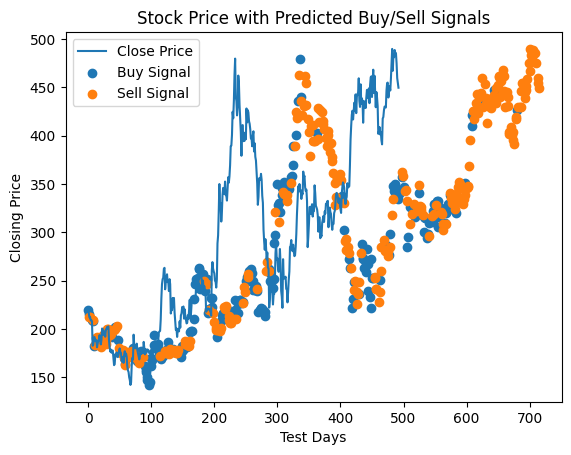

In [ ]:
plt.figure()

plt.plot(df_test['Close'].values)

buy = df_test[df_test['Prediction'] == 1]
sell = df_test[df_test['Prediction'] == 0]

# Convert TimedeltaIndex to numerical days for plotting
plt.scatter((buy.index - df_test.index[0]).days, buy['Close'])
plt.scatter((sell.index - df_test.index[0]).days, sell['Close'])

plt.title("Stock Price with Predicted Buy/Sell Signals")
plt.xlabel("Test Days")
plt.ylabel("Closing Price")
plt.legend(["Close Price", "Buy Signal", "Sell Signal"])

plt.show()